Dataset loaded successfully!
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

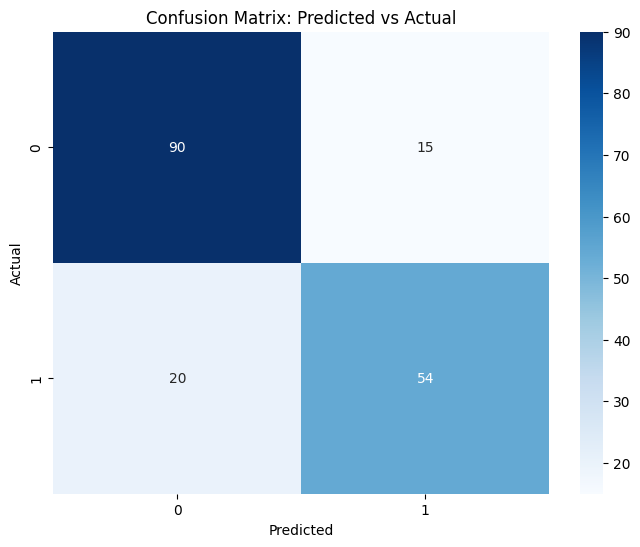

In [6]:
# 1. IMPORTING NECESSARY LIBRARIES 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize df as None so we can check if it loaded
df = None

try:
    # Everything inside 'try' MUST be indented
    df = pd.read_csv(r"C:\Users\admin\Downloads\titanic_data.csv")
    print("Dataset loaded successfully!")
    print(df.head())
except Exception as e:
    print(f"Error loading data: {e}. Please check if 'titanic_data.csv' is in the folder.")

# Only run the rest if the data was actually loaded
if df is not None:
    # 2. FEATURE SELECTION & PREPROCESSING 
    cols_to_use = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare'] 
    df = df[cols_to_use] 

    # Handling Missing Values
    df['Age'] = df['Age'].fillna(df['Age'].median()) 

    # Encoding Categorical Data
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}) 

    # 3. DATA SPLITTING 
    X = df.drop('Survived', axis=1) 
    y = df['Survived'] 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

    # 4. MODEL TRAINING 
    model = RandomForestClassifier(n_estimators=100, random_state=42) 
    model.fit(X_train, y_train) 

    # 5. EVALUATION 
    y_pred = model.predict(X_test) 

    accuracy = accuracy_score(y_test, y_pred) 
    print(f"\n--- MODEL PERFORMANCE ---") 
    print(f"Accuracy Score: {accuracy * 100:.2f}%") 
    print("\nClassification Report:\n", classification_report(y_test, y_pred)) 

    # Visualizing the Confusion Matrix 
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues') 
    plt.title('Confusion Matrix: Predicted vs Actual') 
    plt.xlabel('Predicted') 
    plt.ylabel('Actual') 
    plt.show()